In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

import joblib

In [2]:
df = pd.read_csv("telecom_churn.csv")

df.head()

,gender,SeniorCitizen,Partner,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,Churn
0,Male,0,No,32,48,1503,No,Month-to-month,Electronic check,0
1,Female,0,Yes,12,47,543,No,Two year,Electronic check,0
2,Male,1,Yes,58,95,5495,DSL,Month-to-month,Credit card,0
3,Female,1,Yes,28,117,3269,DSL,Month-to-month,Credit card,0
4,Male,1,No,34,25,893,Fiber,Two year,Electronic check,0


In [3]:
print(df.shape)

df.info()

df.describe()

(500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           500 non-null    object
 1   SeniorCitizen    500 non-null    int64 
 2   Partner          500 non-null    object
 3   tenure           500 non-null    int64 
 4   MonthlyCharges   500 non-null    int64 
 5   TotalCharges     500 non-null    int64 
 6   InternetService  500 non-null    object
 7   Contract         500 non-null    object
 8   PaymentMethod    500 non-null    object
 9   Churn            500 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 39.2+ KB


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.472000,37.458000,71.968000,2703.410000,0.108000
std,0.499715,20.113013,27.974562,1869.645417,0.310691
min,0.000000,1.000000,20.000000,35.000000,0.000000
25%,0.000000,19.000000,50.000000,1189.750000,0.000000
50%,0.000000,38.000000,71.000000,2277.500000,0.000000
75%,1.000000,56.000000,95.000000,4069.500000,0.000000
max,1.000000,72.000000,120.000000,8412.000000,1.000000


In [4]:
df.isnull().sum()

gender             0
SeniorCitizen      0
Partner            0
tenure             0
MonthlyCharges     0
TotalCharges       0
InternetService    0
Contract           0
PaymentMethod      0
Churn              0
dtype: int64

In [5]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [6]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,Churn
0,1,0,0,32,48,1503,2,0,2,0
1,0,0,1,12,47,543,2,2,2,0
2,1,1,1,58,95,5495,0,0,1,0
3,0,1,1,28,117,3269,0,0,1,0
4,1,1,0,34,25,893,1,2,2,0


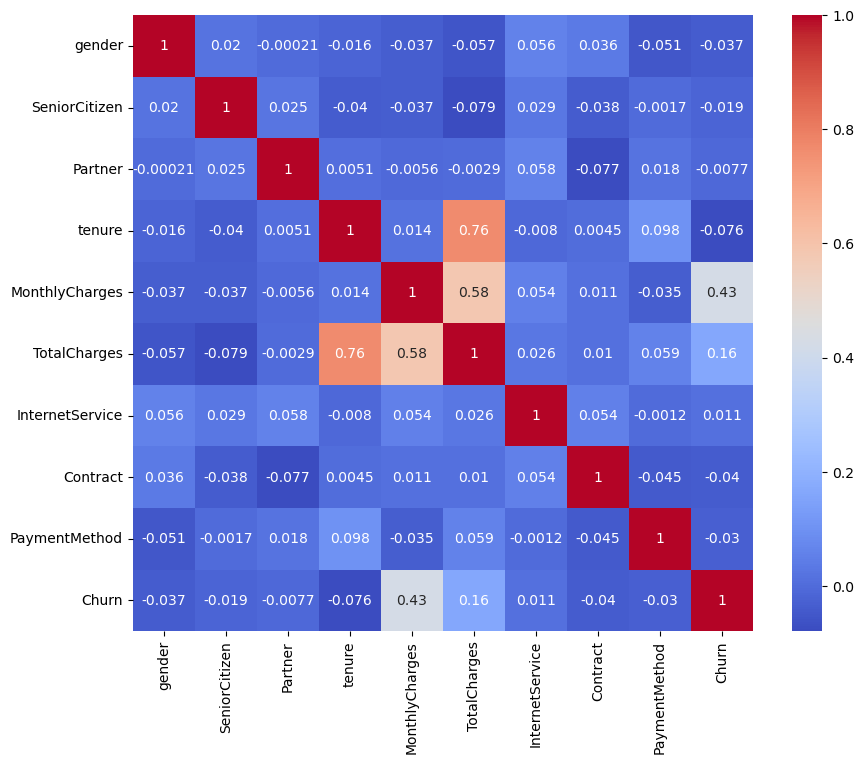

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

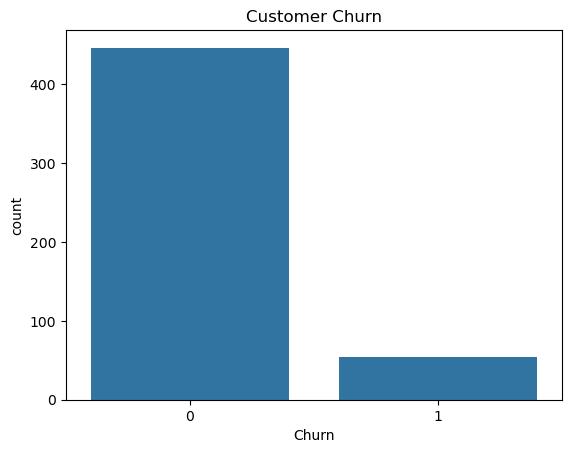

In [8]:
sns.countplot(x="Churn",data=df)

plt.title("Customer Churn")

plt.show()

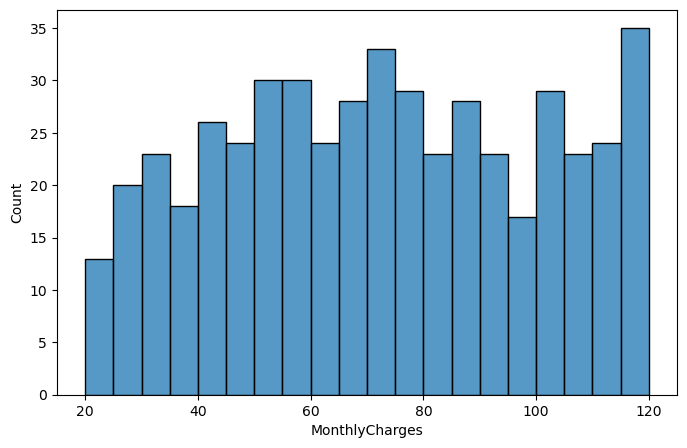

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"],bins=20)

plt.show()

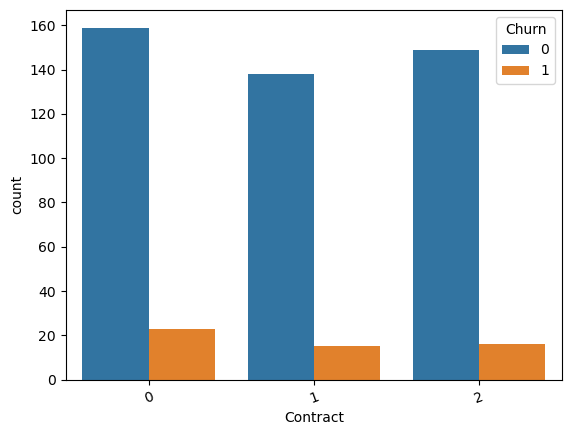

In [10]:
sns.countplot(x="Contract",hue="Churn",data=df)

plt.xticks(rotation=20)

plt.show()

In [11]:
X = df.drop("Churn",axis=1)

y = df["Churn"]

In [12]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

In [13]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test,rf_pred))

print(classification_report(y_test,rf_pred))

Random Forest Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [14]:
xgb = XGBClassifier(

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy")

print(accuracy_score(y_test,xgb_pred))

print(classification_report(y_test,xgb_pred))

XGBoost Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        10

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



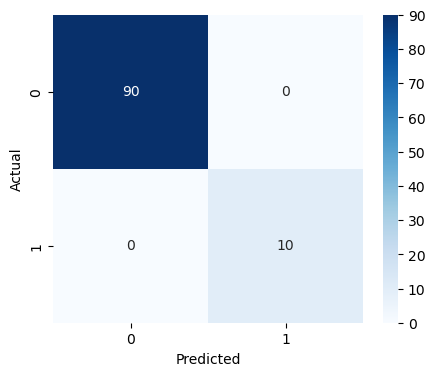

In [15]:
cm = confusion_matrix(

    y_test,

    xgb_pred

)

plt.figure(figsize=(5,4))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

ROC AUC Score : 1.0


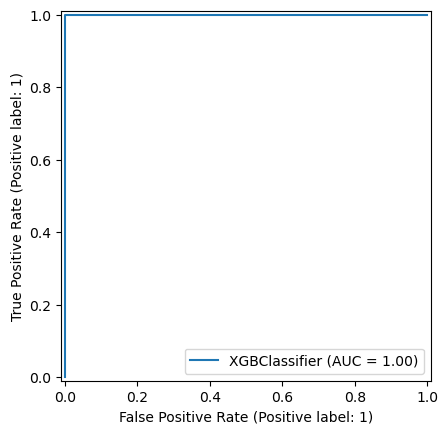

In [16]:
prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test,prob)

print("ROC AUC Score :",auc)

RocCurveDisplay.from_estimator(

    xgb,

    X_test,

    y_test

)

plt.show()

In [17]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance


,Feature,Importance
6,InternetService,0.478035
4,MonthlyCharges,0.383340
3,tenure,0.052557
7,Contract,0.041123
5,TotalCharges,0.027442
1,SeniorCitizen,0.005725
2,Partner,0.005254
0,gender,0.004973
8,PaymentMethod,0.001551


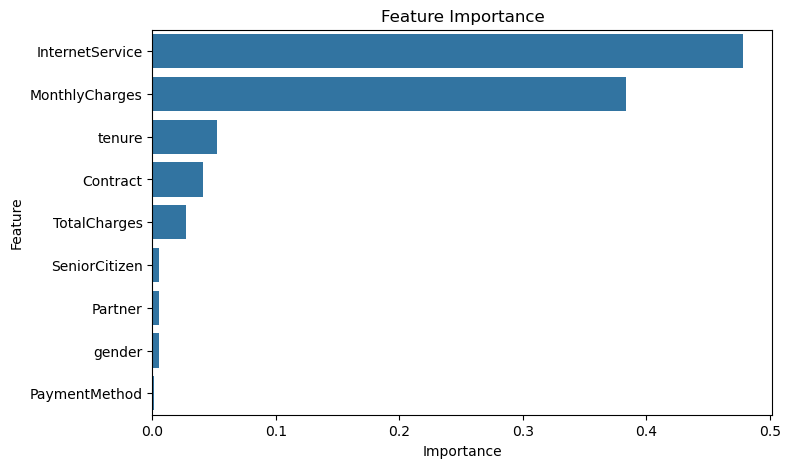

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [19]:
joblib.dump(

    xgb,

    "telecom_churn_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [20]:
sample = pd.DataFrame({

    "gender":[1],

    "SeniorCitizen":[0],

    "Partner":[1],

    "tenure":[24],

    "MonthlyCharges":[85],

    "TotalCharges":[2040],

    "InternetService":[0],

    "Contract":[1],

    "PaymentMethod":[2]

})

prediction = xgb.predict(sample)

if prediction[0] == 1:

    print("Customer Will Churn")

else:

    print("Customer Will Stay")

Customer Will Stay
